/workspace/arushi/miniconda3/envs/torchfem2/lib/python3.13/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


  OED TRAINING DATA GENERATION
  Job ID: 0
  Number of samples: 1
  Mean_vx distribution: N(0.5, 0.2²)
  Drone position distribution: N(0.5, 0.15²)
Using base seed: 1773960648 (based on current time + job_id offset)

  Mesh DOFs: 3721
  Fourier modes: 3 (parameter dim: 14)
  NN input dim: 22

  [1/1] seed=1773960649 mean_vx=0.424
    Computing initial EIG...
    Initial EIG = 9.89
    → EIG: 9.89 → 22.47 (gain=12.59) conv=True [616.0s]

  JOB 0 COMPLETE
  Successful samples: 1 / 1
  Success rate: 100.0%
  Total time: 0.2 hours
  Avg time per sample: 616.1s

  EIG range: 22.47 to 22.47
  EIG mean: 22.47 ± 0.00
  Converged: 1/1

  Saved to oed_training_data_job0.pkl
Loading oed_training_data_combined.pkl...

DATA SUMMARY
Type of data: <class 'list'>
Number of samples: 80

First sample type: <class 'dict'>
First sample keys: ['seed', 'c_init', 'mean_vx', 'nn_input', 'nn_output', 'eig_init', 'eig_opt', 'eig_gain', 'converged', 'wind_coeffs', 'time', 'nit', 'nfev']

STATISTICS
EIG optimal:


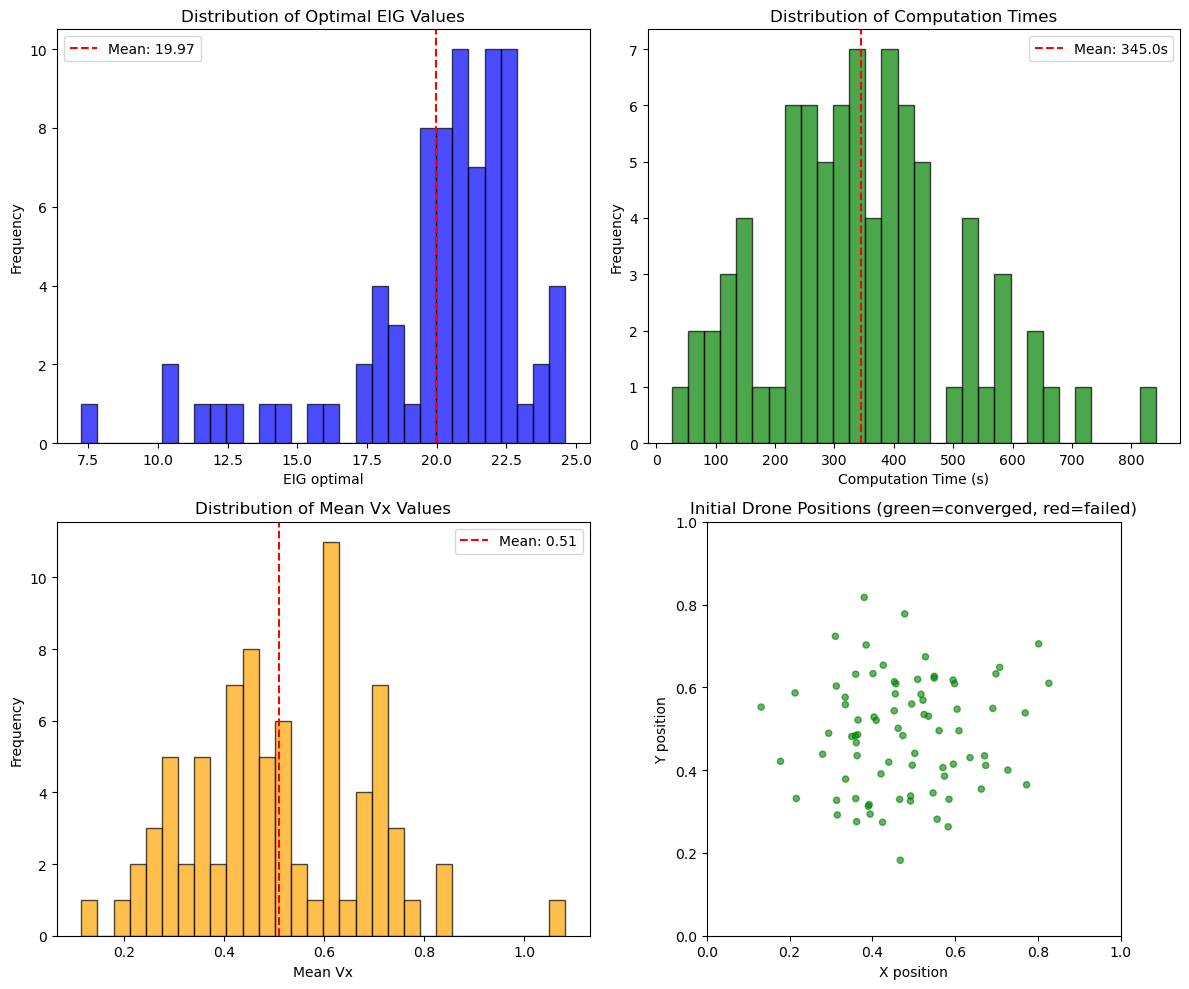


SAMPLE VISUALIZATION

Visualizing sample 0:
  seed: 1773958911
  c_init: [0.280, 0.439]
  mean_vx: 0.639
  eig_init: 12.567
  eig_opt: 22.665
  converged: True
  Setting up finite element spaces...
  Reconstructing wind field...
  Generating plot...
  Saved plot to sample_0_visualization.png


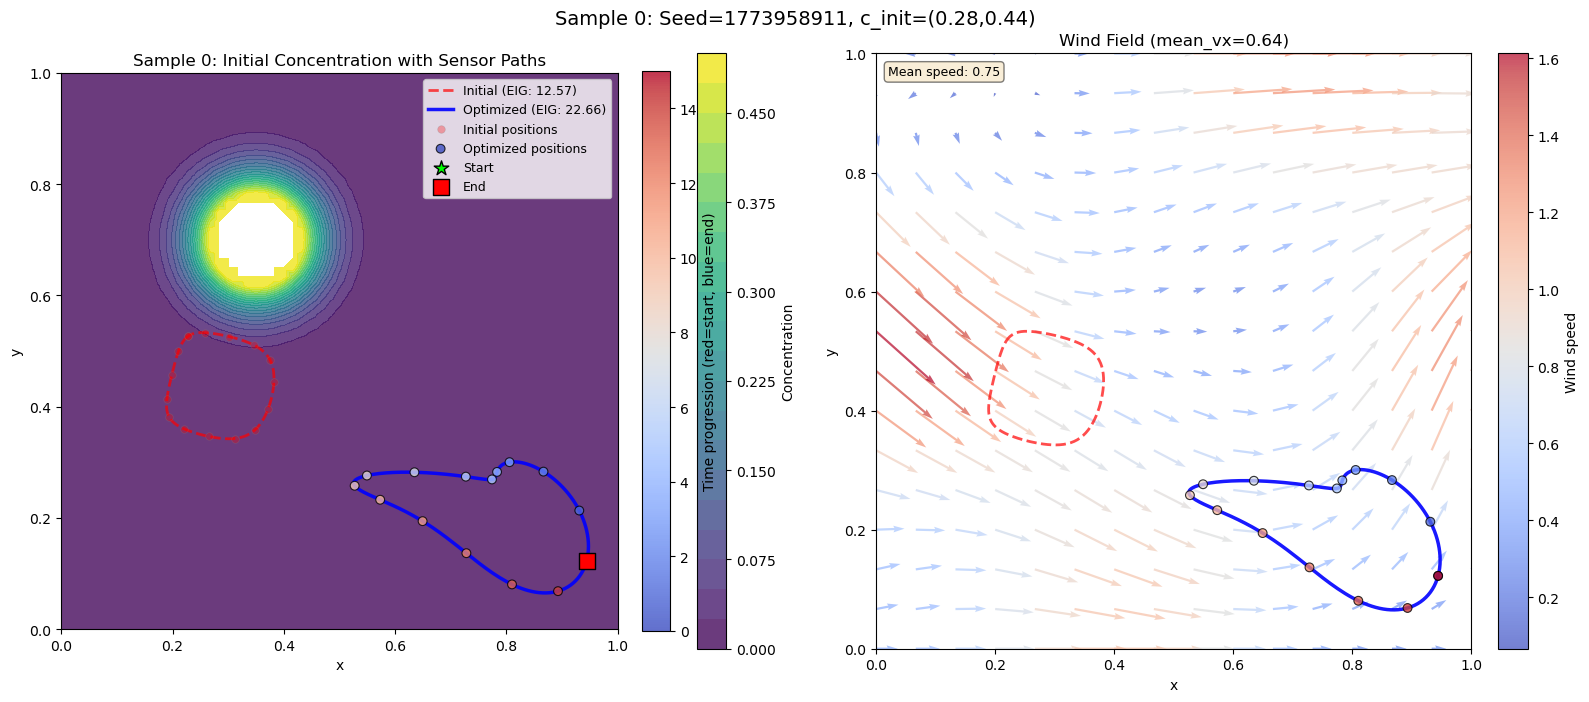


Visualizing sample 79:
  seed: 1782958921
  c_init: [0.360, 0.331]
  mean_vx: 0.707
  eig_init: 7.460
  eig_opt: 13.031
  converged: True
  Setting up finite element spaces...
  Reconstructing wind field...
  Generating plot...
  Saved plot to sample_79_visualization.png


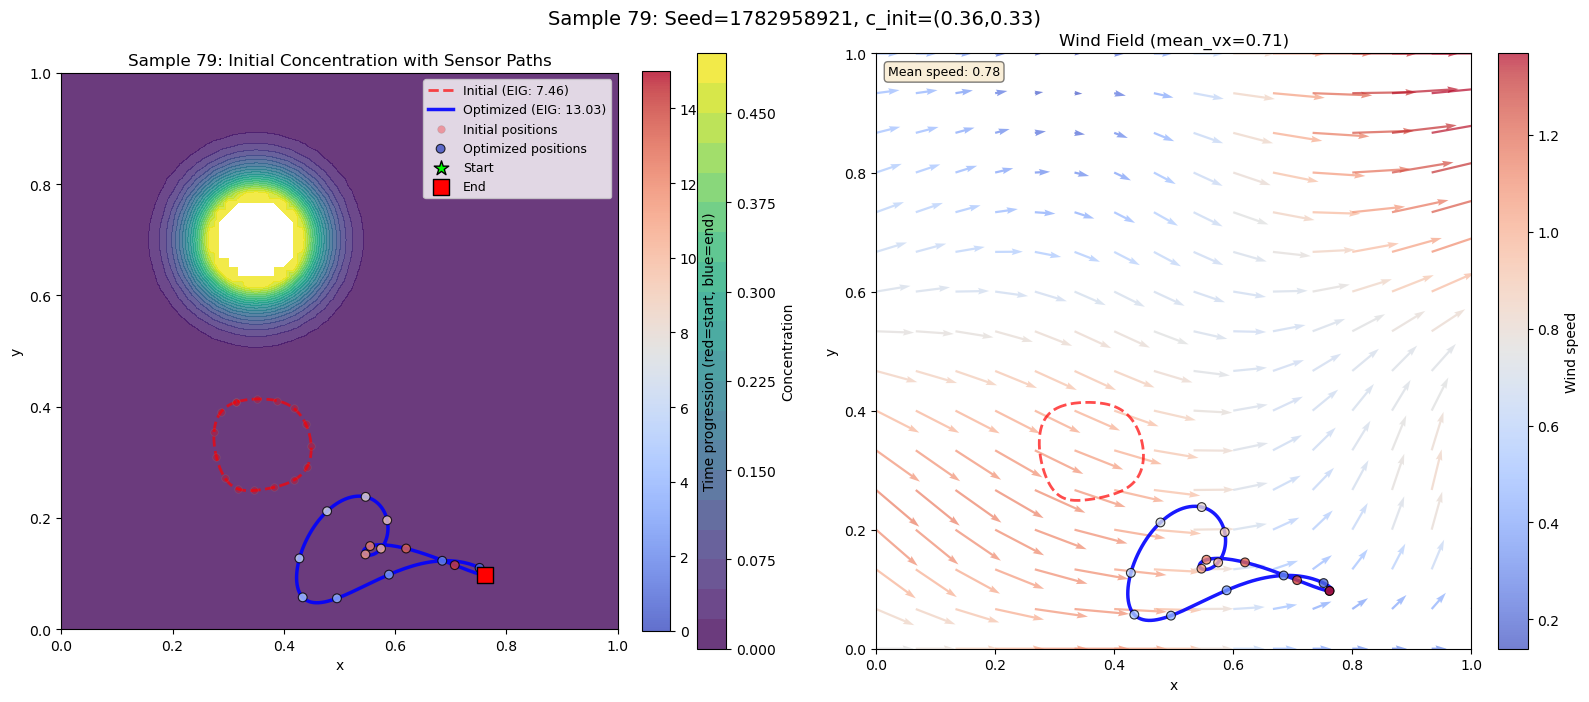

In [1]:
#!/usr/bin/env python3
"""
Script to read and inspect the OED training data pickle file.
Allows visualization of specific samples with initial/optimized paths, wind field, and concentration.
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
import dolfin as dl
import sys
import os

# Add paths for hippylib and model_ad_diff if needed
sys.path.append(os.environ.get('HIPPYLIB_BASE_DIR', "../"))
from hippylib import *

sys.path.append(os.environ.get('HIPPYLIB_BASE_DIR', "..") + "/applications/ad_diff/")
sys.path.append('../../')
from model_ad_diff_bwd import TimeDependentAD

# Import our modules
from fourier_utils import generate_targets, fourier_frequencies
from wind_utils import sample_spectral_wind
from fe_setup import setup_fe_spaces, setup_prior, setup_true_initial_condition
from moving_sensor import MovingSensorMisfit
from training_data_generator import create_initial_guess
from config import TY, K, OBSERVATION_TIMES

# Suppress FEniCS logging
import logging
logging.getLogger('FFC').setLevel(logging.WARNING)
logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

# Load the data
filename = 'oed_training_data_combined.pkl'  # or your combined file
print(f"Loading {filename}...")

with open(filename, 'rb') as f:
    data = pickle.load(f)

print(f"\n{'='*60}")
print(f"DATA SUMMARY")
print(f"{'='*60}")
print(f"Type of data: {type(data)}")
print(f"Number of samples: {len(data)}")

# Check if it's a list of dictionaries
if isinstance(data, list) and len(data) > 0:
    sample = data[0]
    print(f"\nFirst sample type: {type(sample)}")
    print(f"First sample keys: {list(sample.keys())}")
    
    # Print basic statistics
    print(f"\n{'='*60}")
    print(f"STATISTICS")
    print(f"{'='*60}")
    
    # Extract values
    eigs = [d['eig_opt'] for d in data]
    times = [d['time'] for d in data]
    converged = [d['converged'] for d in data]
    mean_vx = [d['mean_vx'] for d in data]
    
    # Check if eig_init exists
    has_eig_init = 'eig_init' in data[0]
    if has_eig_init:
        eig_init = [d['eig_init'] for d in data]
        eig_gain = [d['eig_gain'] for d in data]
    
    print(f"EIG optimal:")
    print(f"  Mean: {np.mean(eigs):.3f}")
    print(f"  Std:  {np.std(eigs):.3f}")
    print(f"  Min:  {np.min(eigs):.3f}")
    print(f"  Max:  {np.max(eigs):.3f}")
    
    if has_eig_init:
        print(f"\nEIG initial:")
        print(f"  Mean: {np.mean(eig_init):.3f}")
        print(f"  Std:  {np.std(eig_init):.3f}")
        print(f"\nEIG gain (opt - init):")
        print(f"  Mean: {np.mean(eig_gain):.3f}")
        print(f"  Std:  {np.std(eig_gain):.3f}")
        print(f"  Min:  {np.min(eig_gain):.3f}")
        print(f"  Max:  {np.max(eig_gain):.3f}")
    
    print(f"\nOptimization time (seconds):")
    print(f"  Mean: {np.mean(times):.1f}")
    print(f"  Std:  {np.std(times):.1f}")
    print(f"  Min:  {np.min(times):.1f}")
    print(f"  Max:  {np.max(times):.1f}")
    
    print(f"\nConvergence:")
    print(f"  Converged: {sum(converged)}/{len(converged)} ({100*sum(converged)/len(converged):.1f}%)")
    
    print(f"\nMean Vx distribution:")
    print(f"  Mean: {np.mean(mean_vx):.3f}")
    print(f"  Std:  {np.std(mean_vx):.3f}")
    print(f"  Min:  {np.min(mean_vx):.3f}")
    print(f"  Max:  {np.max(mean_vx):.3f}")
    
    # Print first few samples
    print(f"\n{'='*60}")
    print(f"FIRST 3 SAMPLES")
    print(f"{'='*60}")
    for i in range(min(3, len(data))):
        print(f"\nSample {i}:")
        print(f"  seed: {data[i]['seed']}")
        print(f"  c_init: [{data[i]['c_init'][0]:.3f}, {data[i]['c_init'][1]:.3f}]")
        print(f"  mean_vx: {data[i]['mean_vx']:.3f}")
        if has_eig_init:
            print(f"  eig_init: {data[i]['eig_init']:.3f}")
        print(f"  eig_opt: {data[i]['eig_opt']:.3f}")
        print(f"  converged: {data[i]['converged']}")
        print(f"  time: {data[i]['time']:.1f}s")
        print(f"  nn_input shape: {data[i]['nn_input'].shape}")
        print(f"  nn_output shape: {data[i]['nn_output'].shape}")
        if 'nit' in data[i]:
            print(f"  iterations: {data[i]['nit']}")
        if 'nfev' in data[i]:
            print(f"  function evaluations: {data[i]['nfev']}")
    
    # Print NN input/output dimensions
    print(f"\n{'='*60}")
    print(f"NEURAL NETWORK DIMENSIONS")
    print(f"{'='*60}")
    print(f"Input dimension: {len(data[0]['nn_input'])}")
    print(f"Output dimension: {len(data[0]['nn_output'])}")
    
    # Quick visualization
    print(f"\n{'='*60}")
    print(f"GENERATING QUICK PLOTS")
    print(f"{'='*60}")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # EIG distribution
    axes[0, 0].hist(eigs, bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 0].axvline(np.mean(eigs), color='red', linestyle='--', label=f'Mean: {np.mean(eigs):.2f}')
    axes[0, 0].set_xlabel('EIG optimal')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Optimal EIG Values')
    axes[0, 0].legend()
    
    # Computation time
    axes[0, 1].hist(times, bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[0, 1].axvline(np.mean(times), color='red', linestyle='--', label=f'Mean: {np.mean(times):.1f}s')
    axes[0, 1].set_xlabel('Computation Time (s)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Computation Times')
    axes[0, 1].legend()
    
    # Mean Vx distribution
    axes[1, 0].hist(mean_vx, bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1, 0].axvline(np.mean(mean_vx), color='red', linestyle='--', label=f'Mean: {np.mean(mean_vx):.2f}')
    axes[1, 0].set_xlabel('Mean Vx')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Mean Vx Values')
    axes[1, 0].legend()
    
    # Initial positions
    c_init_x = [d['c_init'][0] for d in data]
    c_init_y = [d['c_init'][1] for d in data]
    colors = ['green' if d['converged'] else 'red' for d in data]
    scatter = axes[1, 1].scatter(c_init_x, c_init_y, c=colors, alpha=0.6, s=20)
    axes[1, 1].set_xlabel('X position')
    axes[1, 1].set_ylabel('Y position')
    axes[1, 1].set_title('Initial Drone Positions (green=converged, red=failed)')
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig('training_data_summary.png', dpi=150)
    print("Saved plot to training_data_summary.png")
    plt.show()
    
    # Check for failed samples
    failed = [d for d in data if not d['converged']]
    if failed:
        print(f"\n{'='*60}")
        print(f"FAILED SAMPLES ({len(failed)})")
        print(f"{'='*60}")
        for i, f in enumerate(failed[:5]):  # Show first 5 failures
            print(f"  {i}: seed={f['seed']}, c_init=({f['c_init'][0]:.2f},{f['c_init'][1]:.2f}), "
                  f"mean_vx={f['mean_vx']:.2f}, eig={f['eig_opt']:.2f}")
    
    # ===== NEW SECTION: INTERACTIVE SAMPLE VISUALIZATION =====
    print(f"\n{'='*60}")
    print(f"SAMPLE VISUALIZATION")
    print(f"{'='*60}")
    
    while True:
        try:
            idx_input = input(f"\nEnter sample index to visualize (0-{len(data)-1}) or 'q' to quit: ")
            if idx_input.lower() == 'q':
                break
            
            idx = int(idx_input)
            if idx < 0 or idx >= len(data):
                print(f"Index out of range. Please enter 0-{len(data)-1}")
                continue
            
            sample = data[idx]
            print(f"\nVisualizing sample {idx}:")
            print(f"  seed: {sample['seed']}")
            print(f"  c_init: [{sample['c_init'][0]:.3f}, {sample['c_init'][1]:.3f}]")
            print(f"  mean_vx: {sample['mean_vx']:.3f}")
            if 'eig_init' in sample:
                print(f"  eig_init: {sample['eig_init']:.3f}")
            print(f"  eig_opt: {sample['eig_opt']:.3f}")
            print(f"  converged: {sample['converged']}")
            
            # Setup FE spaces
            print("  Setting up finite element spaces...")
            mesh, Vh, _ = setup_fe_spaces()
            
            # Get true initial condition for concentration background
            true_ic = setup_true_initial_condition(Vh)
            true_ic_func = dl.Function(Vh, true_ic)
            
            # Get wind field from coefficients
            print("  Reconstructing wind field...")
            wind_coeffs = sample['wind_coeffs']
            wind_velocity, _ = sample_spectral_wind(
                mesh,
                r_wind=wind_coeffs['r_wind'],
                sigma=wind_coeffs['sigma'],
                alpha=wind_coeffs['alpha'],
                mean_vx=wind_coeffs['mean_vx'],
                mean_vy=wind_coeffs['mean_vy'],
                seed=sample['seed']
            )
            
            # Get initial and optimized paths
            from config import TY, K, OBSERVATION_TIMES
            omegas = fourier_frequencies(TY, K)
            
            # Initial path (using c_init to create initial guess)
            from training_data_generator import create_initial_guess
            m_init = create_initial_guess(sample['c_init'], K)
            
            t_dense = np.linspace(OBSERVATION_TIMES[0], OBSERVATION_TIMES[-1], 200)
            path_init = generate_targets(m_init, t_dense, K, omegas)
            path_opt = generate_targets(sample['nn_output'], t_dense, K, omegas)
            
            # Sensor positions at observation times
            sensors_init = generate_targets(m_init, OBSERVATION_TIMES, K, omegas)
            sensors_opt = generate_targets(sample['nn_output'], OBSERVATION_TIMES, K, omegas)
            
            # Create visualization
            print("  Generating plot...")
            fig, axes = plt.subplots(1, 2, figsize=(16, 7))
            
            # Plot 1: Concentration background with paths
            ax1 = axes[0]
            
            # Plot concentration
            coords = Vh.tabulate_dof_coordinates()
            ic_arr = true_ic.get_local()
            contour = ax1.tricontourf(coords[:, 0], coords[:, 1], ic_arr, 
                                       levels=20, cmap='viridis', alpha=0.8)
            plt.colorbar(contour, ax=ax1, fraction=0.046, pad=0.04, label='Concentration')
            
            # Plot paths
            ax1.plot(path_init[:, 0], path_init[:, 1], 'r--', lw=2, alpha=0.7, 
                     label=f'Initial (EIG: {sample.get("eig_init", 0):.2f})')
            ax1.plot(path_opt[:, 0], path_opt[:, 1], 'b-', lw=2.5, alpha=0.9,
                     label=f'Optimized (EIG: {sample["eig_opt"]:.2f})')
            
            # Plot sensor positions with color gradient from red to blue
            # Create a color array based on time index
            n_sensors = len(sensors_opt)
            colors_opt = plt.cm.coolwarm(np.linspace(0, 1, n_sensors))  # Red (0) to Blue (1)
            # Alternative colormaps: plt.cm.RdYlBu, plt.cm.jet, plt.cm.plasma

            ax1.scatter(sensors_init[:, 0], sensors_init[:, 1], 
                    c='red', s=30, alpha=0.3, edgecolors='gray', linewidths=0.5, zorder=5, 
                    label='Initial positions')

            # Plot with gradient
            sc = ax1.scatter(sensors_opt[:, 0], sensors_opt[:, 1], 
                            c=range(n_sensors),  # Use indices for color mapping
                            cmap='coolwarm',     # Red to blue colormap
                            s=40, alpha=0.8, 
                            edgecolors='black', linewidths=0.8, zorder=5,
                            label='Optimized positions')

            # Add colorbar to show time progression
            cbar = plt.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
            cbar.set_label('Time progression (red=start, blue=end)')

            
            # Mark start and end
            ax1.scatter(sensors_opt[0, 0], sensors_opt[0, 1], 
                       c='lime', s=120, marker='*', edgecolors='black', linewidths=1, zorder=6, label='Start')
            ax1.scatter(sensors_opt[-1, 0], sensors_opt[-1, 1], 
                       c='red', s=120, marker='s', edgecolors='black', linewidths=1, zorder=6, label='End')
            
            ax1.set_xlim(0, 1)
            ax1.set_ylim(0, 1)
            ax1.set_aspect('equal', 'box')
            ax1.set_xlabel('x')
            ax1.set_ylabel('y')
            ax1.set_title(f'Sample {idx}: Initial Concentration with Sensor Paths')
            ax1.legend(loc='upper right', fontsize=9)
            
            # Plot 2: Wind field with paths
            ax2 = axes[1]
            
            # Wind quiver on coarse grid
            mc_q = dl.UnitSquareMesh(15, 15)
            vc_q = dl.interpolate(wind_velocity, dl.VectorFunctionSpace(mc_q, "CG", 1))
            coords_q = mc_q.coordinates()
            vals_q = vc_q.compute_vertex_values(mc_q)
            n_q = len(coords_q)
            
            speed_field = np.sqrt(vals_q[:n_q]**2 + vals_q[n_q:]**2)
            quiver = ax2.quiver(coords_q[:, 0], coords_q[:, 1],
                                vals_q[:n_q], vals_q[n_q:],
                                speed_field, cmap='coolwarm', alpha=0.7, scale=12)
            plt.colorbar(quiver, ax=ax2, fraction=0.046, pad=0.04, label='Wind speed')
            
            # Plot paths on wind field
            ax2.plot(path_init[:, 0], path_init[:, 1], 'r--', lw=2, alpha=0.7)
            ax2.plot(path_opt[:, 0], path_opt[:, 1], 'b-', lw=2.5, alpha=0.9)
            # Plot with gradient on wind field too
            sc2 = ax2.scatter(sensors_opt[:, 0], sensors_opt[:, 1], 
                            c=range(n_sensors),
                            cmap='coolwarm',
                            s=40, alpha=0.8, 
                            edgecolors='black', linewidths=0.8, zorder=5)
            
            ax2.set_xlim(0, 1)
            ax2.set_ylim(0, 1)
            ax2.set_aspect('equal', 'box')
            ax2.set_xlabel('x')
            ax2.set_ylabel('y')
            ax2.set_title(f'Wind Field (mean_vx={sample["mean_vx"]:.2f})')
            
            # Add wind statistics
            vx_vals = vals_q[:n_q]
            vy_vals = vals_q[n_q:]
            mean_speed = np.mean(np.sqrt(vx_vals**2 + vy_vals**2))
            ax2.text(0.02, 0.98, f'Mean speed: {mean_speed:.2f}', 
                    transform=ax2.transAxes, fontsize=9,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            plt.suptitle(f'Sample {idx}: Seed={sample["seed"]}, c_init=({sample["c_init"][0]:.2f},{sample["c_init"][1]:.2f})', 
                        fontsize=14)
            plt.tight_layout()
            plt.savefig(f'viz/sample_{idx}_visualization.png', dpi=150)
            print(f"  Saved plot to sample_{idx}_visualization.png")
            plt.show()
            
        except ValueError:
            print("Invalid input. Please enter a number or 'q'.")
        except Exception as e:
            print(f"Error visualizing sample: {e}")
            import traceback
            traceback.print_exc()

else:
    print(f"Unexpected data format: {type(data)}")
    if isinstance(data, dict):
        print(f"Dictionary keys: {list(data.keys())}")

In [2]:
data


[{'seed': 1773958911,
  'c_init': array([0.2798638 , 0.43859415]),
  'mean_vx': 0.6389824999776147,
  'nn_input': array([ 6.38982500e-01,  0.00000000e+00,  3.47456250e-01, -8.18744712e-02,
         -7.98871489e-02, -2.41367020e-01, -3.03450113e-01, -3.10460628e-04,
          1.25141411e-01,  1.13037124e-01, -8.14313277e-02, -7.33787342e-01,
          8.87976580e-02, -1.44757388e-01, -5.77555577e-02,  2.52336925e-01,
          6.67647691e-02,  1.11697300e-01,  2.47662970e-02,  1.11676161e-01,
          2.79863798e-01,  4.38594147e-01]),
  'nn_output': array([ 0.74644503,  0.21834364, -0.14693186,  0.10147664, -0.02261653,
         -0.09302055, -0.04375488,  0.00327012,  0.04722331, -0.00822829,
          0.01734162,  0.0182731 , -0.01017686,  0.01274938]),
  'eig_init': 12.567042663779628,
  'eig_opt': 22.6648684584379,
  'eig_gain': 10.097825794658274,
  'converged': True,
  'wind_coeffs': {'a_ij': array([[ 3.47456250e-01, -8.18744712e-02, -7.98871489e-02],
          [-2.41367020e-01, 